# ✈️ U.S. Flight Delay Analysis

## Project Overview

This project analyzes U.S. flight data to identify patterns associated with flight delays and severe delays.

A flight is classified as delayed when its departure delay is **15 minutes or more**, while a severe delay is defined as **60 minutes or more**.

### Main Business Questions

- Which airlines have the highest delay rates?
- How do delay rates change by month, day of week, and time of day?
- Are certain airports or flight routes associated with higher delay rates?
- What are the most common delay causes?
- Does flight distance relate to delay frequency?
- What factors characterize severe delays of 60 minutes or more?

The goal is to identify meaningful patterns in the dataset and present them through clear analysis and visualizations.

## 1. Data Overview & Preparation

Before starting the analysis, the dataset was explored and prepared to ensure that the variables used in the analysis were suitable and consistent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Data Dictionary

The data dictionary provides information about the variables in the flight dataset, including data types, missing-value percentages, and example values.

In [2]:
data_dictionary = pd.read_csv('flight_data_2024_data_dictionary.csv')

data_dictionary.head(10)

,column,dtype,null_pct,example_value
0,year,Int64,0.0,2024
1,month,Int64,0.0,1
2,day_of_month,Int64,0.0,1
3,day_of_week,Int64,0.0,1
4,fl_date,datetime64[ns],0.0,2024-01-01 00:00:00
5,op_unique_carrier,object,0.0,9E
6,op_carrier_fl_num,float64,0.0,4814.0
7,origin,object,0.0,JFK
8,origin_city_name,object,0.0,"New York, NY"
9,origin_state_nm,object,0.0,New York


### Loading the Flight Dataset

The main flight dataset was loaded into a Pandas DataFrame. A preview of the first rows was used to inspect the dataset structure and verify that the data was loaded correctly.

In [3]:
flights = pd.read_csv('flight_data_2024_sample.csv')

In [4]:
flights.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


### Initial Data Inspection

The dataset contains 10,000 flight records and 35 variables.  
The structure, data types, and missing values were inspected before beginning the analysis.

In [5]:
flights.shape

(10000, 35)

In [6]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  str    
 5   op_unique_carrier    10000 non-null  str    
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  str    
 8   origin_city_name     10000 non-null  str    
 9   origin_state_nm      10000 non-null  str    
 10  dest                 10000 non-null  str    
 11  dest_city_name       10000 non-null  str    
 12  dest_state_nm        10000 non-null  str    
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   float64
 16

### Missing Values Check

Missing values were examined to identify columns that may require cleaning or special treatment before the analysis.

In [7]:
flights.isna().sum()

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
op_unique_carrier         0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
crs_dep_time              0
dep_time                116
dep_delay               116
taxi_out                120
wheels_off              120
wheels_on               127
taxi_in                 127
crs_arr_time              0
arr_time                127
arr_delay               164
cancelled                 0
cancellation_code      9878
diverted                  0
crs_elapsed_time          0
actual_elapsed_time     164
air_time                164
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
dtype: int64

### Cancelled Flights

Cancelled flights were examined because they do not have a normal departure delay and should not be treated as regular completed flights in the delay analysis.

Out of 10,000 flight records, 122 flights were cancelled.

Inspection of the cancelled flights showed that operational fields such as departure time and departure delay may be missing because the flight never departed.

In [8]:
flights['cancelled'].value_counts()

cancelled
0    9878
1     122
Name: count, dtype: int64

In [9]:
flights[flights['cancelled'] == 1][
    ['fl_date', 'op_unique_carrier', 'origin', 'dest',
     'dep_time', 'dep_delay', 'cancelled', 'cancellation_code']
]

,fl_date,op_unique_carrier,origin,dest,dep_time,dep_delay,cancelled,cancellation_code
24,2024-01-16,AA,DFW,MCI,NaN,NaN,1,B
122,2024-07-20,9E,CHO,ATL,NaN,NaN,1,A
200,2024-01-12,AS,SFO,EWR,NaN,NaN,1,A
264,2024-02-01,WN,DAL,LAS,NaN,NaN,1,C
333,2024-05-28,AA,DFW,DCA,NaN,NaN,1,B
...,...,...,...,...,...,...,...,...
9553,2024-10-09,WN,MHT,MCO,NaN,NaN,1,B
9727,2024-07-22,DL,SAT,MSP,NaN,NaN,1,A
9906,2024-01-07,UA,EWR,MIA,NaN,NaN,1,A
9923,2024-07-20,9E,MSP,OMA,NaN,NaN,1,A


#### Data Consistency Check

A consistency check identified 6 flights marked as cancelled that still contained a recorded departure time. Therefore, cancellation status was used explicitly when preparing the dataset rather than relying only on missing departure-time values.

In [10]:
flights[
    (flights['cancelled'] == 1) &
    (flights['dep_time'].notna())
][
    ['fl_date', 'op_unique_carrier', 'origin', 'dest',
     'dep_time', 'dep_delay', 'cancelled', 'cancellation_code']
]

,fl_date,op_unique_carrier,origin,dest,dep_time,dep_delay,cancelled,cancellation_code
2068,2024-07-31,9E,GSO,LGA,1546.0,51.0,1,C
2844,2024-01-08,AS,SAN,MCO,1141.0,-8.0,1,A
3330,2024-02-09,AA,SNA,ORD,721.0,-9.0,1,A
4608,2024-01-20,OO,LAX,RDM,1615.0,0.0,1,B
6812,2024-06-19,AS,ANC,ADK,1130.0,0.0,1,B
8205,2024-04-20,MQ,GCK,DFW,600.0,25.0,1,C


### Descriptive Statistics

Summary statistics were reviewed to understand the distributions and ranges of the numerical variables and to identify potentially unusual values.

In [11]:
flights.describe()

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,10000.0,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,9884.000000,9884.000000,9880.000000,9880.000000,...,10000.000000,10000.000000,9836.000000,9836.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2024.0,6.613200,15.843000,3.95020,2529.762600,1324.447700,1330.160664,13.002428,17.878644,1353.564879,...,0.004200,147.372500,141.727837,115.445506,838.346600,4.870900,1.083100,3.027100,0.008800,6.142200
std,0.0,3.377858,8.792774,2.00637,1655.998442,488.544631,504.953299,53.614819,9.773379,507.452551,...,0.064674,72.931101,72.786088,70.736184,598.526507,33.502392,15.821031,15.755545,0.381231,29.632624
min,2024.0,1.000000,1.000000,1.00000,1.000000,22.000000,1.000000,-22.000000,4.000000,1.000000,...,0.000000,23.000000,17.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024.0,4.000000,8.000000,2.00000,1172.000000,905.000000,910.000000,-6.000000,12.000000,928.750000,...,0.000000,93.000000,89.000000,64.000000,404.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024.0,7.000000,16.000000,4.00000,2254.000000,1320.000000,1324.000000,-2.000000,15.000000,1337.000000,...,0.000000,130.000000,125.000000,98.000000,680.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.0,10.000000,23.000000,6.00000,3742.000000,1734.250000,1745.000000,9.250000,21.000000,1759.000000,...,0.000000,179.000000,174.000000,145.000000,1072.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024.0,12.000000,31.000000,7.00000,8771.000000,2359.000000,2400.000000,2011.000000,154.000000,2400.000000,...,1.000000,685.000000,691.000000,635.000000,5095.000000,2011.000000,664.000000,454.000000,22.000000,995.000000


### Extreme Delay Inspection

The descriptive statistics revealed an unusually high maximum departure delay of 2,011 minutes. The corresponding flight was inspected to determine whether the value should be considered in the analysis.

In [12]:
flights[
    flights['dep_delay'] == flights['dep_delay'].max()
][
    ['fl_date', 'op_unique_carrier', 'origin', 'dest', 'dep_delay']
]

,fl_date,op_unique_carrier,origin,dest,dep_delay
9506,2024-06-17,AA,SDF,MIA,2011.0


### Duplicate Records Check

The dataset was checked for duplicate records. No duplicate rows were found.

In [13]:
flights.duplicated().sum()

np.int64(0)

### Date Conversion

The `fl_date` column was converted to datetime format to support time-based analysis.

In [14]:
flights['fl_date'] = pd.to_datetime(flights['fl_date'])

In [15]:
flights['fl_date'].dtype

dtype('<M8[us]')

### Diverted Flights and Analysis Dataset

The dataset contains 42 diverted flights.

Cancelled and diverted flights were identified separately because they do not represent normally completed flights and may contain incomplete or non-comparable delay information.

A total of 164 records were either cancelled or diverted. These records were excluded from the main delay analysis to create a consistent dataset of completed, non-diverted flights.

In [16]:
flights['diverted'].value_counts()

diverted
0    9958
1      42
Name: count, dtype: int64

In [17]:
flights[
    (flights['cancelled'] == 1) |
    (flights['diverted'] == 1)
].shape

(164, 35)

In [18]:
flights[flights['arr_delay'].isna()][
    ['cancelled', 'diverted']
].value_counts()

cancelled  diverted
1          0           122
0          1            42
Name: count, dtype: int64

The missing arrival-delay values were fully explained by cancelled and diverted flights: 122 cancelled flights and 42 diverted flights. This supports excluding these records from the main delay analysis rather than treating the missing values as random missing data.

### Airline Representation

The number of flights represented by each airline was examined to understand the sample distribution and to identify airlines with relatively small sample sizes.

This is important when comparing delay rates, since percentages based on a small number of flights should be interpreted with greater caution.

In [19]:
flights['op_unique_carrier'].value_counts()

op_unique_carrier
WN    2022
DL    1459
AA    1385
OO    1080
UA    1033
YX     434
MQ     406
NK     361
B6     331
OH     326
AS     323
F9     295
9E     278
G4     172
HA      95
Name: count, dtype: int64

### Delay Classification

For the analysis, a flight was classified as delayed when its departure delay was 15 minutes or more.

A Boolean variable named `is_delayed` was created to support delay-rate calculations throughout the project.

In [20]:
flights['is_delayed'] = flights['dep_delay'] >= 15

### Analysis Dataset Preparation

For the delay analysis, a filtered dataset was created containing only flights suitable for departure-delay analysis.

Cancelled flights, diverted flights, and records without a departure-delay value were excluded.

After filtering, **9,836 flights** remained for the analysis.

In [21]:
valid_flights = flights[
    (flights['cancelled'] == 0) &
    (flights['diverted'] == 0) &
    (flights['dep_delay'].notna())
].copy()

In [22]:
valid_flights.shape

(9836, 36)

## 2. Delay Analysis

### Delay Rate by Airline

The delay rate was calculated as the percentage of valid flights with a departure delay of 15 minutes or more.

In [23]:
valid_flights.groupby('op_unique_carrier')['is_delayed'].mean().sort_values(ascending=False) * 100

op_unique_carrier
AA    27.205882
F9    27.083333
B6    25.304878
NK    24.285714
WN    23.632715
G4    22.941176
OH    22.468354
UA    20.197044
AS    17.777778
DL    17.463617
MQ    17.042607
OO    16.682287
9E    13.235294
YX    10.093897
HA     7.446809
Name: is_delayed, dtype: float64

### Key Finding

American Airlines (AA) had the highest delay rate in the sample at **27.2%**, closely followed by Frontier Airlines (F9) at **27.1%**.

Hawaiian Airlines (HA) had the lowest delay rate at **7.4%**.

The results show noticeable variation in delay rates across airlines, suggesting that delay frequency differs considerably between carriers in this sample.

### Delay Rate by Month

Delay rates were compared across months to identify seasonal patterns in flight delays.

In [24]:
valid_flights.groupby( 'month' )[ 'is_delayed' ].mean().sort_values(ascending=False)*100

month
7     32.766440
6     25.304136
1     23.570432
8     23.103851
5     22.721750
3     22.342995
12    21.132075
4     19.881657
11    17.002519
9     15.042118
2     14.245416
10    11.682744
Name: is_delayed, dtype: float64

### Key Finding

July had the highest delay rate in the sample at **32.8%**, followed by June at **25.3%**.

October had the lowest delay rate at **11.7%**.

The results indicate clear monthly variation in delay frequency, with the highest delay rates occurring during the summer months in this sample.

### Average Departure Delay by Month

Average departure delay was also compared across months to examine whether months with higher delay rates also tended to have longer delays.

In [25]:
valid_flights.groupby('month')['dep_delay'].mean().sort_values(ascending=False)

month
7     25.724490
6     17.210462
5     16.950182
12    15.603774
8     15.231039
1     14.563459
3     13.365942
4     11.650888
11     8.328715
2      6.873061
9      6.364621
10     2.762058
Name: dep_delay, dtype: float64

July had the highest average departure delay at **25.7 minutes**, while October had the lowest at **2.8 minutes**.

This is consistent with the delay-rate analysis, where July had the highest share of delayed flights and October the lowest.

### Airport Sample Size

The number of flights originating from each airport was examined before comparing airport delay rates.

The dataset contains flights from 284 origin airports, but the number of observations varies substantially between airports. To avoid drawing conclusions from airports with very small samples, the delay analysis will focus on airports with at least 50 valid flights.

In [26]:
valid_flights.groupby('origin').size().sort_values(ascending=False)

origin
ATL    487
DFW    428
DEN    408
ORD    387
CLT    314
      ... 
SIT      1
SPI      1
SLN      1
WRG      1
WYS      1
Length: 283, dtype: int64

### Delay Rate by Origin Airport

Delay rates were compared across origin airports.

Because some airports have very few observations in the dataset, only airports with at least 50 valid flights were included in the comparison. This reduces the risk of drawing conclusions from very small samples.

In [27]:
airport_counts = valid_flights.groupby('origin').size()

large_airports = airport_counts[airport_counts >= 50].index

In [28]:
large_airport_flights = valid_flights[
    valid_flights['origin'].isin(large_airports)
]

In [29]:
large_airport_flights.groupby('origin')['is_delayed'].mean().sort_values(ascending=False) * 100

origin
IAD    31.343284
MIA    30.625000
BWI    30.370370
PIT    28.985507
DFW    27.102804
CLT    27.070064
LAS    26.086957
AUS    25.581395
DAL    25.242718
MDW    25.210084
FLL    24.832215
DEN    24.754902
MCO    24.434389
ORD    23.772610
BNA    23.717949
RDU    23.529412
BUR    22.222222
SFO    22.162162
MSY    22.033898
PHX    21.527778
LAX    20.863309
IAH    20.645161
MCI    20.312500
MSP    20.238095
PHL    20.161290
SEA    20.098039
SJU    20.000000
RSW    19.672131
DCA    19.653179
DTW    19.473684
JFK    18.848168
ATL    18.685832
EWR    18.652850
HOU    18.461538
OAK    18.000000
LGA    17.903930
SAN    17.605634
TPA    16.666667
STL    16.455696
PDX    16.304348
SAT    16.071429
SJC    15.277778
BOS    15.183246
SLC    13.740458
SMF    13.265306
IND    12.698413
CVG    11.940299
HNL    10.869565
Name: is_delayed, dtype: float64

#### Key Finding

Among origin airports with at least 50 valid flights in the sample, IAD had the highest delay rate at **31.3%**, followed closely by MIA at **30.6%** and BWI at **30.4%**.

The results show meaningful variation in delay frequency across origin airports. The minimum threshold of 50 flights was used to avoid drawing conclusions from airports with very small sample sizes.

### Average Departure Delay by Origin Airport

Average departure delay was compared across the selected origin airports to examine not only how frequently delays occur, but also their overall magnitude.

In [30]:
large_airport_flights.groupby('origin')['dep_delay' ].mean().sort_values(ascending=False)

origin
PIT    30.565217
SJU    21.127273
CLT    20.563694
IAD    20.238806
MIA    19.850000
IAH    19.090323
DFW    18.796729
RSW    18.606557
FLL    16.100671
DEN    15.438725
BNA    15.166667
EWR    15.031088
ORD    14.472868
BWI    14.429630
LAS    14.095652
AUS    14.054264
DCA    13.959538
SFO    13.881081
MCO    13.805430
RDU    13.352941
LGA    13.061135
MDW    12.739496
TPA    12.108333
PHL    12.024194
MSY    11.508475
BOS    11.371728
LAX    11.305755
DTW    11.189474
PHX    11.076389
DAL    10.601942
IND    10.476190
ATL    10.470226
SJC    10.236111
STL     9.101266
SLC     8.938931
CVG     8.776119
HOU     8.384615
MSP     7.851190
OAK     7.580000
PDX     7.554348
MCI     7.281250
SAN     6.612676
SEA     6.387255
SMF     6.285714
BUR     6.148148
JFK     5.575916
SAT     3.607143
HNL     3.423913
Name: dep_delay, dtype: float64

#### Key Finding

PIT had the highest average departure delay at **30.6 minutes**, followed by SJU at **21.1 minutes** and CLT at **20.6 minutes**.

The airport with the highest average delay was not the same as the airport with the highest delay rate, showing that delay frequency and average delay duration capture different aspects of flight performance.

In [31]:
large_airport_flights.groupby('origin')['dep_delay'].median().sort_values(ascending=False)

origin
BWI    3.0
MDW    1.0
DAL    0.0
AUS    0.0
IAD    0.0
MIA    0.0
HOU    0.0
OAK    0.0
PIT    0.0
PHX   -0.5
MCO   -1.0
CLT   -1.0
FLL   -1.0
DFW   -1.0
DEN   -1.0
BNA   -1.0
SJC   -1.0
SAN   -1.0
LAS   -1.0
TPA   -1.0
MSY   -1.0
HNL   -1.5
ATL   -2.0
RDU   -2.0
SMF   -2.0
SAT   -2.0
SJU   -2.0
ORD   -2.0
IND   -2.0
IAH   -2.0
MSP   -2.0
MCI   -2.0
SFO   -2.0
PHL   -2.0
RSW   -2.0
SEA   -2.5
DCA   -3.0
BUR   -3.0
DTW   -3.0
EWR   -3.0
STL   -3.0
SLC   -3.0
JFK   -3.0
LAX   -3.0
LGA   -4.0
BOS   -4.0
PDX   -4.0
CVG   -5.0
Name: dep_delay, dtype: float64

In [96]:
large_airport_flights.groupby('origin')['dep_delay'].mean().sort_values(ascending=False)

origin
PIT    30.565217
SJU    21.127273
CLT    20.563694
IAD    20.238806
MIA    19.850000
IAH    19.090323
DFW    18.796729
RSW    18.606557
FLL    16.100671
DEN    15.438725
BNA    15.166667
EWR    15.031088
ORD    14.472868
BWI    14.429630
LAS    14.095652
AUS    14.054264
DCA    13.959538
SFO    13.881081
MCO    13.805430
RDU    13.352941
LGA    13.061135
MDW    12.739496
TPA    12.108333
PHL    12.024194
MSY    11.508475
BOS    11.371728
LAX    11.305755
DTW    11.189474
PHX    11.076389
DAL    10.601942
IND    10.476190
ATL    10.470226
SJC    10.236111
STL     9.101266
SLC     8.938931
CVG     8.776119
HOU     8.384615
MSP     7.851190
OAK     7.580000
PDX     7.554348
MCI     7.281250
SAN     6.612676
SEA     6.387255
SMF     6.285714
BUR     6.148148
JFK     5.575916
SAT     3.607143
HNL     3.423913
Name: dep_delay, dtype: float64

#### Mean vs. Median

Although PIT had the highest average departure delay at **30.6 minutes**, its median departure delay was **0 minutes**.

This large difference between the mean and median suggests that the average is being influenced by a smaller number of unusually long delays. Therefore, average delay alone does not represent the typical flight experience.

### Delay Causes Analysis

The dataset includes five categories of delay causes: carrier, weather, air traffic system (NAS), security, and late-arriving aircraft.

Before comparing the causes, the relevant columns were checked for missing values.

In [32]:
flights[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]].isna().sum()   

carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [33]:
flights[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]].sum()   

carrier_delay          48709
weather_delay          10831
nas_delay              30271
security_delay            88
late_aircraft_delay    61422
dtype: int64

In [34]:
(flights[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]] > 0).sum()

carrier_delay          1136
weather_delay           141
nas_delay              1056
security_delay            6
late_aircraft_delay    1065
dtype: int64

In [35]:
delay_columns = [
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]

flights[delay_columns].where(
    flights[delay_columns] > 0
).mean().sort_values(ascending=False)


weather_delay          76.815603
late_aircraft_delay    57.673239
carrier_delay          42.877641
nas_delay              28.665720
security_delay         14.666667
dtype: float64

#### Key Finding

The analysis shows an important distinction between delay frequency and delay severity.

**Carrier delays** were the most frequent, affecting **1,136 flights**, while **late-arriving aircraft delays** accounted for the largest total amount of delay time at **61,422 minutes**.

**Weather delays** were much less frequent, affecting only **141 flights**, but when they occurred they were the most severe, averaging **76.8 minutes**.

This demonstrates that the most frequent cause of delay is not necessarily the cause associated with the longest delays.

### Flight Distance and Delays

Flight distance was examined to determine whether delay patterns differ between shorter and longer flights.

The distribution of flight distances was first reviewed before dividing the flights into distance groups.

In [36]:
flights['distance'].describe()

count    10000.000000
mean       838.346600
std        598.526507
min         31.000000
25%        404.000000
50%        680.000000
75%       1072.000000
max       5095.000000
Name: distance, dtype: float64

In [37]:
flights['distance_group'] = pd.qcut(
    flights['distance'],
    q=4,
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

In [38]:
flights['distance_group'].value_counts()

distance_group
Short        2524
Very Long    2497
Medium       2491
Long         2488
Name: count, dtype: int64

In [39]:
valid_flights['distance_group'] = pd.qcut(
    valid_flights['distance'],
    q=4,
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

In [40]:
valid_flights.groupby('distance_group')['is_delayed'].mean() * 100

distance_group
Short        18.910126
Medium       20.016175
Long         21.186094
Very Long    22.936153
Name: is_delayed, dtype: float64

#### Key Finding

The delay rate increased gradually with flight distance.

Short flights had the lowest delay rate at **18.9%**, followed by Medium flights at **20.0%** and Long flights at **21.2%**. Very Long flights had the highest delay rate at **22.9%**.

This suggests a positive association between flight distance and the frequency of departure delays in this sample. However, the analysis does not establish that longer flight distance itself causes delays.

In [41]:
delay_by_distance = valid_flights.groupby('distance_group')['is_delayed'].mean() * 100

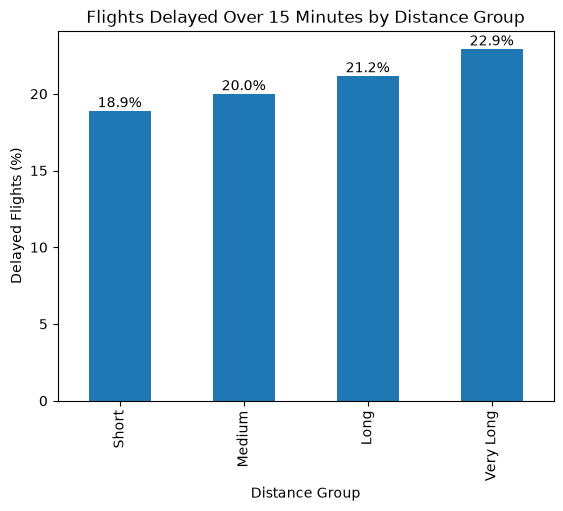

In [97]:
ax = delay_by_distance.plot(
    kind='bar',
    title='Flights Delayed Over 15 Minutes by Distance Group'
)

ax.set_xlabel('Distance Group')
ax.set_ylabel('Delayed Flights (%)')

ax.bar_label(ax.containers[0], fmt='%.1f%%');

### Delay Rate by Time of Day

The scheduled departure time was converted into an hourly variable to examine whether delay rates vary throughout the day.

In [43]:
valid_flights['dep_hour'] = valid_flights['crs_dep_time'] // 100

In [44]:
valid_flights['dep_hour'].value_counts().sort_index()

dep_hour
0      13
1       7
2       2
3       3
4       1
5     278
6     682
7     689
8     667
9     546
10    629
11    569
12    632
13    607
14    562
15    574
16    582
17    623
18    633
19    531
20    400
21    315
22    217
23     74
Name: count, dtype: int64

In [45]:
valid_flights['time_of_day'] = pd.cut(
    valid_flights['dep_hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [46]:
valid_flights['time_of_day'].value_counts()

time_of_day
Morning      3782
Afternoon    3580
Evening      2170
Night         304
Name: count, dtype: int64

In [47]:
delay_by_time = (
    valid_flights.groupby('time_of_day')['is_delayed']
    .mean() * 100
)

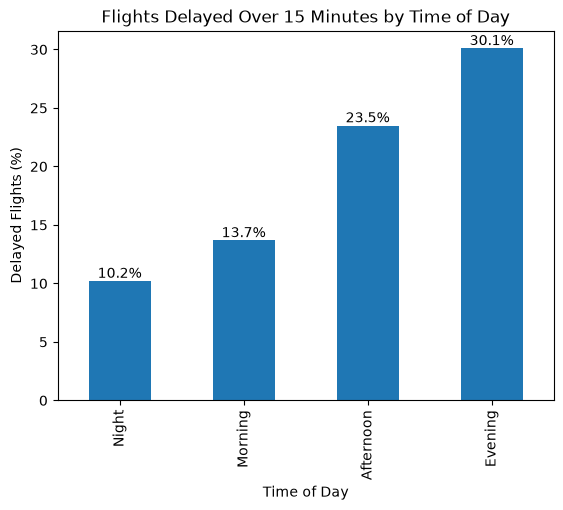

In [48]:
ax = delay_by_time.plot(
    kind='bar',
    title='Flights Delayed Over 15 Minutes by Time of Day'
)

ax.set_xlabel('Time of Day')
ax.set_ylabel('Delayed Flights (%)')

ax.bar_label(ax.containers[0], fmt='%.1f%%');

#### Key Finding

Delay rates increased substantially throughout the day, from **10.2%** during the Night period and **13.7%** in the Morning to **23.5%** in the Afternoon and **30.1%** in the Evening.

This indicates a strong association between scheduled departure time and delay frequency in this sample, with evening flights experiencing the highest delay rate.

The Night group contains substantially fewer flights than the other time periods, so its result should be interpreted with some caution.

In [49]:
valid_flights['is_late_aircraft'] = valid_flights['late_aircraft_delay'] > 0

In [50]:
valid_flights.groupby('time_of_day')['is_late_aircraft'].mean() * 100

time_of_day
Night         1.973684
Morning       4.362771
Afternoon    13.770950
Evening      18.479263
Name: is_late_aircraft, dtype: float64

In [51]:
valid_flights[
    valid_flights['late_aircraft_delay'] > 0
].groupby('time_of_day')['late_aircraft_delay'].mean()

time_of_day
Night        58.166667
Morning      68.163636
Afternoon    55.040568
Evening      56.586035
Name: late_aircraft_delay, dtype: float64

#### Late Aircraft Delays by Time of Day

Late-aircraft delays became substantially more frequent as the day progressed, increasing from **2.0%** of flights at Night and **4.4%** in the Morning to **13.8%** in the Afternoon and **18.5%** in the Evening.

However, when a late-aircraft delay occurred, its average duration did not increase throughout the day. This suggests that the time-of-day pattern is primarily associated with an increase in the **frequency** of late-aircraft delays rather than their **severity**.

This pattern may help explain part of the higher overall delay rate observed later in the day, although it does not establish a causal relationship.

### Delay Rate by Day of Week

Delay rates were analyzed across the days of the week to determine whether departure delays follow a weekly pattern.

In [52]:
valid_flights['day_of_week'].value_counts().sort_index()

day_of_week
1    1530
2    1376
3    1298
4    1521
5    1437
6    1279
7    1395
Name: count, dtype: int64

In [53]:
day_names = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

valid_flights['day_name'] = valid_flights['day_of_week'].map(day_names)

In [54]:
delay_by_day = (
    valid_flights.groupby('day_name')['is_delayed'].mean() * 100
)

In [55]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

delay_by_day = delay_by_day.reindex(day_order)

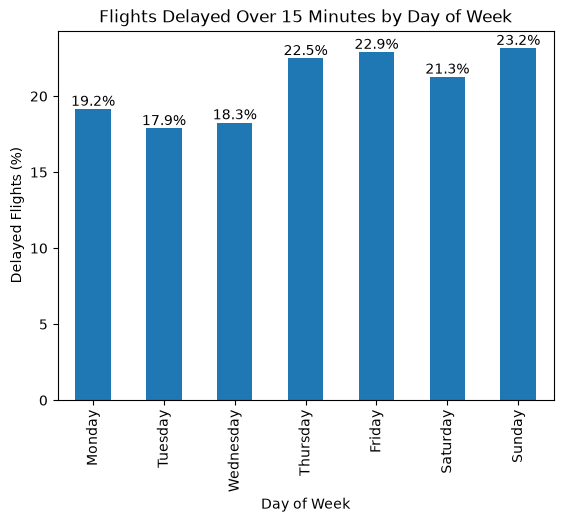

In [56]:
ax = delay_by_day.plot(
    kind='bar',
    title='Flights Delayed Over 15 Minutes by Day of Week'
)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Delayed Flights (%)')

ax.bar_label(ax.containers[0], fmt='%.1f%%');

#### Key Finding

Sunday had the highest delay rate at **23.2%**, followed by Friday at **22.9%** and Thursday at **22.5%**.

Tuesday had the lowest delay rate at **17.9%**.

Overall, delay rates were somewhat higher toward the end of the week, although the differences between days were smaller than the differences observed across times of day.

### Airline and Time-of-Day Interaction

To examine whether the relationship between time of day and delay frequency differs across airlines, the analysis was limited to carriers with at least **300 valid flights** in the sample.

This threshold was used to reduce the influence of very small carrier samples on the comparison.

In [57]:
carrier_counts = valid_flights.groupby('op_unique_carrier').size()

In [58]:
large_carriers = carrier_counts[carrier_counts >= 300].index

large_carriers

Index(['AA', 'AS', 'B6', 'DL', 'MQ', 'NK', 'OH', 'OO', 'UA', 'WN', 'YX'], dtype='str', name='op_unique_carrier')

In [59]:
large_carrier_flights = valid_flights[
    valid_flights['op_unique_carrier'].isin(large_carriers)
]

large_carrier_flights.shape

(9012, 41)

In [60]:
large_carrier_flights.groupby(
    ['op_unique_carrier', 'time_of_day']
)['is_delayed'].mean() * 100

op_unique_carrier  time_of_day
AA                 Night          14.285714
                   Morning        16.756757
                   Afternoon      31.447964
                   Evening        41.719745
AS                 Night           0.000000
                   Morning        11.278195
                   Afternoon      21.875000
                   Evening        25.000000
B6                 Night          12.500000
                   Morning        13.868613
                   Afternoon      31.481481
                   Evening        38.666667
DL                 Night           8.571429
                   Morning        12.591241
                   Afternoon      18.864469
                   Evening        24.522293
MQ                 Night          15.384615
                   Morning        10.948905
                   Afternoon      18.300654
                   Evening        23.958333
NK                 Night          11.111111
                   Morning        13.445378
 

In [61]:
delay_carrier_time = (
    large_carrier_flights
    .groupby(['op_unique_carrier', 'time_of_day'])['is_delayed']
    .mean()
    .mul(100)
    .unstack()
)

delay_carrier_time

time_of_day,Night,Morning,Afternoon,Evening
op_unique_carrier,,,,
AA,14.285714,16.756757,31.447964,41.719745
AS,0.000000,11.278195,21.875000,25.000000
B6,12.500000,13.868613,31.481481,38.666667
DL,8.571429,12.591241,18.864469,24.522293
MQ,15.384615,10.948905,18.300654,23.958333
NK,11.111111,13.445378,26.262626,38.095238
OH,30.000000,12.000000,23.809524,32.500000
OO,17.647059,15.508021,17.633411,16.666667
UA,6.250000,14.698795,19.777159,32.000000


In [62]:
delay_carrier_time['evening_vs_morning'] = (
    delay_carrier_time['Evening'] -
    delay_carrier_time['Morning']
)

In [63]:
delay_carrier_time['evening_vs_morning'].sort_values(ascending=False)

op_unique_carrier
AA    24.962988
B6    24.798054
NK    24.649860
WN    21.916752
OH    20.500000
UA    17.301205
AS    13.721805
MQ    13.009428
DL    11.931052
YX     5.616310
OO     1.158645
Name: evening_vs_morning, dtype: float64

### Key Finding

The effect of time of day varied considerably across airlines.

American Airlines (AA), JetBlue (B6), and Spirit Airlines (NK) showed the largest increases in delay rates from morning to evening, with increases of approximately 25 percentage points.

In contrast, SkyWest Airlines (OO) showed almost no difference between morning and evening delay rates.

This suggests that the increase in delays later in the day is not equally strong across all airlines.

In [64]:
valid_flights.groupby(['origin', 'dest']).size().sort_values(ascending=False)


origin  dest
LAX     JFK     24
OGG     HNL     21
JFK     LAX     20
HNL     OGG     20
LAX     LAS     19
                ..
WYS     SLC      1
WRG     PSG      1
VPS     CLT      1
        BNA      1
TYS     PIE      1
Length: 3565, dtype: int64

In [65]:
route_counts = valid_flights.groupby(['origin', 'dest']).size()

In [66]:
## large_ routes = routes with at least 10 flights 

large_routes = route_counts[route_counts >= 10]
large_routes

origin  dest
ANC     SEA     10
ATL     DFW     11
        DTW     11
        IAD     13
        LGA     10
                ..
SJU     MCO     11
SLC     DEN     10
SMF     LAX     11
        SAN     16
TPA     ATL     10
Length: 89, dtype: int64

In [67]:


route_delay_rate = (
    valid_flights
    .groupby(['origin', 'dest'])['is_delayed']
    .mean() * 100
)

In [68]:

large_route_delay_rate = route_delay_rate.loc[large_routes.index]

In [69]:

large_route_delay_rate = large_route_delay_rate.sort_values(ascending=False)

large_route_delay_rate

origin  dest
ATL     DFW     63.636364
LAX     DFW     50.000000
LGA     FLL     41.666667
MCO     BOS     40.000000
LAS     SAN     40.000000
                  ...    
ORD     LGA      0.000000
        MSP      0.000000
SFO     SEA      0.000000
SMF     LAX      0.000000
SLC     DEN      0.000000
Name: is_delayed, Length: 89, dtype: float64

### Key Finding

Among routes with at least 10 flights in the sample, ATL–DFW had the highest delay rate at 63.6%, followed by LAX–DFW at 50.0%.

Several routes showed substantially higher delay rates than others, indicating that delay frequency may vary considerably by route.

Only routes with at least 10 flights were included to reduce the influence of routes with very small sample sizes.

### Route Summary

To support a more reliable comparison, the number of flights and delay rate were combined for each route with at least 10 flights.

In [70]:


route_summary = pd.DataFrame({
    'Flights': large_routes,
    'Delay_Rate': large_route_delay_rate
})

route_summary

Flights  Delay_Rate
origin dest                     
ANC    SEA        10    0.000000
ATL    DFW        11   63.636364
       DTW        11   27.272727
       IAD        13    7.692308
       LGA        10   30.000000
...              ...         ...
SJU    MCO        11   18.181818
SLC    DEN        10    0.000000
SMF    LAX        11    0.000000
       SAN        16   25.000000
TPA    ATL        10   10.000000

[89 rows x 2 columns]

In [71]:

route_summary = route_summary.reset_index()

route_summary

,origin,dest,Flights,Delay_Rate
0,ANC,SEA,10,0.000000
1,ATL,DFW,11,63.636364
2,ATL,DTW,11,27.272727
3,ATL,IAD,13,7.692308
4,ATL,LGA,10,30.000000
...,...,...,...,...
84,SJU,MCO,11,18.181818
85,SLC,DEN,10,0.000000
86,SMF,LAX,11,0.000000
87,SMF,SAN,16,25.000000


In [72]:

route_summary = route_summary.sort_values(
    by='Delay_Rate',
    ascending=False
)

In [73]:

route_summary.head(10)

,origin,dest,Flights,Delay_Rate
1,ATL,DFW,11,63.636364
45,LAX,DFW,12,50.000000
55,LGA,FLL,12,41.666667
60,MCO,BOS,10,40.000000
41,LAS,SAN,10,40.000000
22,DFW,LAS,13,38.461538
25,DTW,ATL,11,36.363636
28,FLL,ATL,11,36.363636
49,LAX,PDX,11,36.363636
9,BOS,ATL,14,35.714286


In [74]:
route_summary.head(10)

,origin,dest,Flights,Delay_Rate
1,ATL,DFW,11,63.636364
45,LAX,DFW,12,50.000000
55,LGA,FLL,12,41.666667
60,MCO,BOS,10,40.000000
41,LAS,SAN,10,40.000000
22,DFW,LAS,13,38.461538
25,DTW,ATL,11,36.363636
28,FLL,ATL,11,36.363636
49,LAX,PDX,11,36.363636
9,BOS,ATL,14,35.714286


In [75]:

route_summary['Route'] = (
    route_summary['origin'] + ' → ' + route_summary['dest']
)

In [76]:

top_10_routes = route_summary.head(10)

In [77]:

top_10_routes[['Route', 'Flights', 'Delay_Rate']]

,Route,Flights,Delay_Rate
1,ATL → DFW,11,63.636364
45,LAX → DFW,12,50.000000
55,LGA → FLL,12,41.666667
60,MCO → BOS,10,40.000000
41,LAS → SAN,10,40.000000
22,DFW → LAS,13,38.461538
25,DTW → ATL,11,36.363636
28,FLL → ATL,11,36.363636
49,LAX → PDX,11,36.363636
9,BOS → ATL,14,35.714286


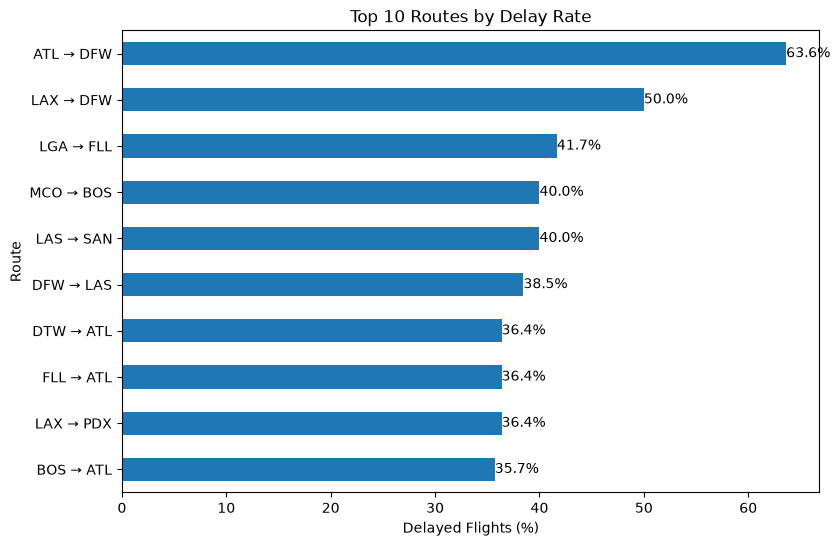

In [78]:
ax = top_10_routes.plot(
    x='Route',
    y='Delay_Rate',
    kind='barh',
    figsize=(9, 6),
    legend=False,
    title='Top 10 Routes by Delay Rate'
)

ax.set_xlabel('Delayed Flights (%)')
ax.set_ylabel('Route')

ax.invert_yaxis()

ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%'
);

In [79]:

destination_counts = (
    valid_flights
    .groupby('dest')
    .size()
    .sort_values(ascending=False)
)

destination_counts

dest
ATL    479
DFW    439
DEN    390
ORD    365
CLT    281
      ... 
BMI      1
SCC      1
WRG      1
WYS      1
XWA      1
Length: 286, dtype: int64

In [80]:

large_destinations = destination_counts[
    destination_counts >= 50
].index

In [81]:

destination_delay_rate = (
    valid_flights[
        valid_flights['dest'].isin(large_destinations)
    ]
    .groupby('dest')['is_delayed']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

destination_delay_rate

dest
OAK    29.090909
SMF    28.000000
PHL    27.210884
SAT    27.142857
PIT    26.984127
LAS    26.353791
MDW    25.225225
FLL    24.770642
MCO    24.644550
TPA    24.561404
CLT    24.555160
SAN    24.218750
DFW    24.145786
BNA    23.943662
HOU    23.863636
SFO    23.857868
PDX    23.684211
BWI    23.076923
MSY    22.727273
DAL    22.429907
EWR    22.093023
PHX    21.897810
AUS    21.428571
BOS    21.311475
MIA    21.153846
SNA    21.052632
RDU    21.052632
DEN    21.025641
ATL    20.459290
RSW    20.370370
JFK    19.897959
IND    19.696970
LGA    19.523810
CVG    19.298246
ORD    18.904110
MCI    18.840580
STL    17.857143
SLC    17.763158
CMH    17.647059
BUR    17.307692
MSP    16.860465
IAH    16.352201
SEA    15.837104
LAX    15.613383
DTW    15.469613
IAD    12.903226
DCA    12.765957
SJC    12.328767
HNL     9.411765
CLE     7.692308
Name: is_delayed, dtype: float64

In [82]:

valid_flights['is_severe_delay'] = valid_flights['dep_delay'] >= 60

In [83]:
valid_flights['is_severe_delay'].sum()

valid_flights['is_severe_delay'].mean() * 100

np.float64(7.858885725904839)

In [84]:

airline_delay_comparison = (
    valid_flights
    .groupby('op_unique_carrier')
    .agg(
        Delay_15_Pct=('is_delayed', 'mean'),
        Severe_60_Pct=('is_severe_delay', 'mean')
    )
    * 100
)

airline_delay_comparison

,Delay_15_Pct,Severe_60_Pct
op_unique_carrier,,
9E,13.235294,8.088235
AA,27.205882,12.205882
AS,17.777778,4.444444
B6,25.304878,9.756098
DL,17.463617,6.444906
F9,27.083333,10.763889
G4,22.941176,9.411765
HA,7.446809,2.127660
MQ,17.042607,5.513784


In [85]:

airline_delay_comparison['Severe_Among_Delayed_Pct'] = (
    airline_delay_comparison['Severe_60_Pct']
    / airline_delay_comparison['Delay_15_Pct']
    * 100
)

In [86]:

airline_delay_comparison.sort_values(
    by='Severe_Among_Delayed_Pct',
    ascending=False
)

,Delay_15_Pct,Severe_60_Pct,Severe_Among_Delayed_Pct
op_unique_carrier,,,
9E,13.235294,8.088235,61.111111
OH,22.468354,12.025316,53.521127
OO,16.682287,7.591378,45.505618
AA,27.205882,12.205882,44.864865
G4,22.941176,9.411765,41.025641
UA,20.197044,8.177340,40.487805
F9,27.083333,10.763889,39.743590
B6,25.304878,9.756098,38.554217
DL,17.463617,6.444906,36.904762


In [87]:

airline_counts = (
    valid_flights
    .groupby('op_unique_carrier')
    .agg(
        Total_Flights=('is_delayed', 'size'),
        Delayed_Flights=('is_delayed', 'sum'),
        Severe_Delays=('is_severe_delay', 'sum')
    )
)

airline_counts 


,Total_Flights,Delayed_Flights,Severe_Delays
op_unique_carrier,,,
9E,272,36,22
AA,1360,370,166
AS,315,56,14
B6,328,83,32
DL,1443,252,93
F9,288,78,31
G4,170,39,16
HA,94,7,2
MQ,399,68,22


In [88]:
valid_flights['dep_hour'] = valid_flights['crs_dep_time'] // 100

valid_flights['time_of_day'] = pd.cut(
    valid_flights['dep_hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [89]:
valid_flights.columns.tolist()

['year',
 'month',
 'day_of_month',
 'day_of_week',
 'fl_date',
 'op_unique_carrier',
 'op_carrier_fl_num',
 'origin',
 'origin_city_name',
 'origin_state_nm',
 'dest',
 'dest_city_name',
 'dest_state_nm',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'taxi_out',
 'wheels_off',
 'wheels_on',
 'taxi_in',
 'crs_arr_time',
 'arr_time',
 'arr_delay',
 'cancelled',
 'cancellation_code',
 'diverted',
 'crs_elapsed_time',
 'actual_elapsed_time',
 'air_time',
 'distance',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'is_delayed',
 'distance_group',
 'dep_hour',
 'time_of_day',
 'is_late_aircraft',
 'day_name',
 'is_severe_delay']

In [90]:
valid_flights['is_severe_delay'] = valid_flights['dep_delay'] >= 60

valid_flights[['dep_delay', 'is_severe_delay']].head()

,dep_delay,is_severe_delay
0,-3.0,False
1,-4.0,False
2,-8.0,False
3,4.0,False
4,-7.0,False


In [91]:
time_delay_comparison = (
    valid_flights
    .groupby('time_of_day')
    .agg(
        Delay_15_Pct=('is_delayed', 'mean'),
        Severe_60_Pct=('is_severe_delay', 'mean')
    )
    * 100
)

time_delay_comparison

,Delay_15_Pct,Severe_60_Pct
time_of_day,,
Night,10.197368,3.289474
Morning,13.670016,4.918033
Afternoon,23.491620,8.826816
Evening,30.092166,12.027650


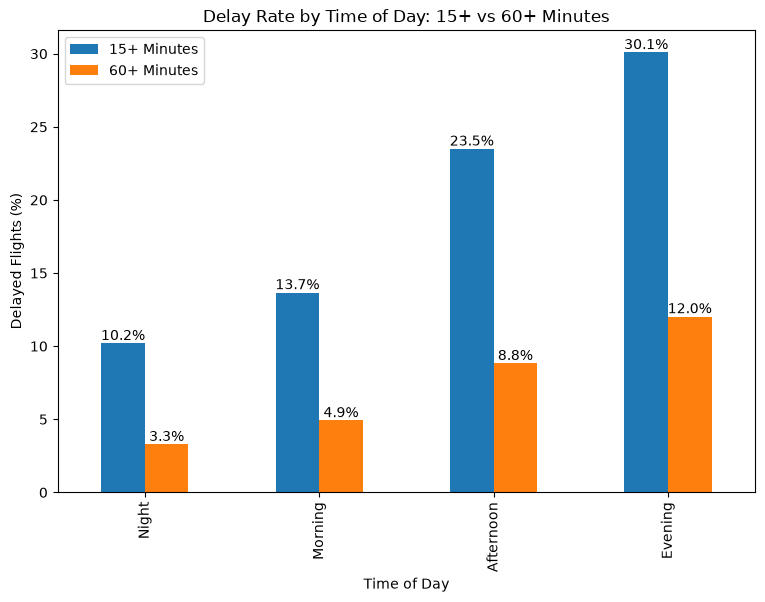

In [92]:

ax = time_delay_comparison.plot(
    kind='bar',
    figsize=(9, 6),
    title='Delay Rate by Time of Day: 15+ vs 60+ Minutes'
)

ax.set_xlabel('Time of Day')
ax.set_ylabel('Delayed Flights (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

ax.legend(['15+ Minutes', '60+ Minutes']);

In [93]:

severe_flights = valid_flights[
    valid_flights['is_severe_delay']
]

In [94]:
severe_cause_counts = (
    severe_flights[delay_columns]
    .gt(0)
    .sum()
    .sort_values(ascending=False)
)

severe_cause_counts

late_aircraft_delay    487
carrier_delay          454
nas_delay              262
weather_delay           81
security_delay           0
dtype: int64

In [95]:
len(severe_flights)

773

### Conclusion

- `late_aircraft_delay` was the most frequently observed cause among severely delayed flights, appearing in 487 of 773 flights (approximately 63.0%).
- `carrier_delay` was also very common, appearing in 454 of 773 flights (approximately 58.7%).
- `nas_delay` appeared in 262 flights (approximately 33.9%).
- `weather_delay` appeared in 81 flights (approximately 10.5%).
- `security_delay` was not observed among the severely delayed flights in this sample.
- A single flight can contain multiple delay causes, so these percentages should not be expected to add up to 100%.

# Final Conclusions

This analysis identified several patterns associated with flight delays in the sample:

- **Time of day was one of the clearest patterns:** delay rates increased from 10.2% at Night and 13.7% in the Morning to 23.5% in the Afternoon and 30.1% in the Evening.

- **Late-aircraft delays became much more frequent later in the day**, increasing from 2.0% at Night to 18.5% in the Evening. Their average duration, however, did not increase throughout the day, suggesting that frequency rather than severity was the main difference.

- **Delay rates increased gradually with flight distance**, from 18.9% for Short flights to 22.9% for Very Long flights.

- **Origin airport was associated with substantial variation in delay rates.** Among airports with at least 50 valid flights, IAD had the highest delay rate at 31.3%, followed by MIA at 30.6% and BWI at 30.4%.

- **Average delay can be misleading when viewed alone.** PIT had the highest average departure delay at 30.6 minutes, while its median delay was 0 minutes, indicating that a smaller number of long delays strongly influenced the average.

- **The time-of-day pattern differed across airlines.** AA, B6, and NK showed increases of approximately 25 percentage points in delay rates from morning to evening, while OO showed almost no difference.

- **Day-of-week differences were present but smaller than time-of-day differences.** Sunday had the highest delay rate at 23.2%, while Tuesday had the lowest at 17.9%.

Overall, the analysis suggests that flight delays in this sample were associated with several operational and scheduling factors, particularly time of day. These findings describe patterns in the available data and should not be interpreted as evidence of causation.